# Experiment 3.2 — the backward viscosity solution recovered by our network

An exactly solvable bimodal field prior on $8\times8$ patches (`pnpreg/bimodal.py`):
nonconvex along one bump direction $u$ (the Experiment-1 mixture), Gaussian with
spectrum $\lambda_k = 4/k^2$ elsewhere. The network trained on denoiser pairs
$(D(z), z)$ solves the backward Hamilton–Jacobi problem — its readout estimates
$f_{\mathrm{reg}} = t\,J_{BVS}$ — and the closed form is the reference. Two fits,
same architecture and budget: the semiconvex readout $J_\theta = G_\theta - \tfrac12\|y\|^2$
and the plain convex control. Produced by

```
~/miniforge3/envs/lpn_env/bin/python -m pnpreg.bimodal_run
```


In [1]:
import json, os, sys
sys.path.insert(0, os.getcwd())
import pandas as pd
from pnpreg import paths
with open(os.path.join(paths.RESULTS, "bimodal_metrics.json")) as f:
    M = json.load(f)
print("run of", M["config"]["date"], "| sigmas", M["config"]["sigmas"],
      "| steps", M["config"]["steps"])
rows = []
for r in M["runs"]:
    for w, name in (("a", "semiconvex readout"), ("b", "convex control")):
        d = r[w]
        rows.append({"sigma": r["sigma"], "fit": name,
                     "rel L2 (values)": d["rel_l2_values"],
                     "perp spectrum rel L2": d["spectrum_rel_l2"],
                     "spectrum worst mode": d.get("spectrum_rel_max_per_mode"),
                     "min curvature (u)": r["curvature"][f"{w}_min"],
                     "resid median": d["resid_median"], "resid q95": d["resid_q95"]})
    rows.append({"sigma": r["sigma"], "fit": "EXACT", "rel L2 (values)": 0.0,
                 "perp spectrum rel L2": 0.0,
                 "min curvature (u)": r["curvature"]["exact_min"],
                 "resid median": 0.0, "resid q95": 0.0})
with pd.option_context("display.float_format", lambda v: f"{v:.4g}"):
    display(pd.DataFrame(rows).set_index(["sigma", "fit"]))

run of 2026-07-31T07:36:59 | sigmas [0.5] | steps 50000


rel L2 (values)  perp spectrum rel L2  \
sigma fit                                                         
0.5   semiconvex readout          0.03201              0.003201   
      convex control               0.1542               0.01127   
      EXACT                             0                     0   

                          spectrum worst mode  min curvature (u)  \
sigma fit                                                          
0.5   semiconvex readout              0.03117            -0.8825   
      convex control                  0.04219          0.0003815   
      EXACT                               NaN            -0.9113   

                          resid median  resid q95  
sigma fit                                          
0.5   semiconvex readout       0.02487     0.0405  
      convex control            0.0449     0.1645  
      EXACT                          0          0

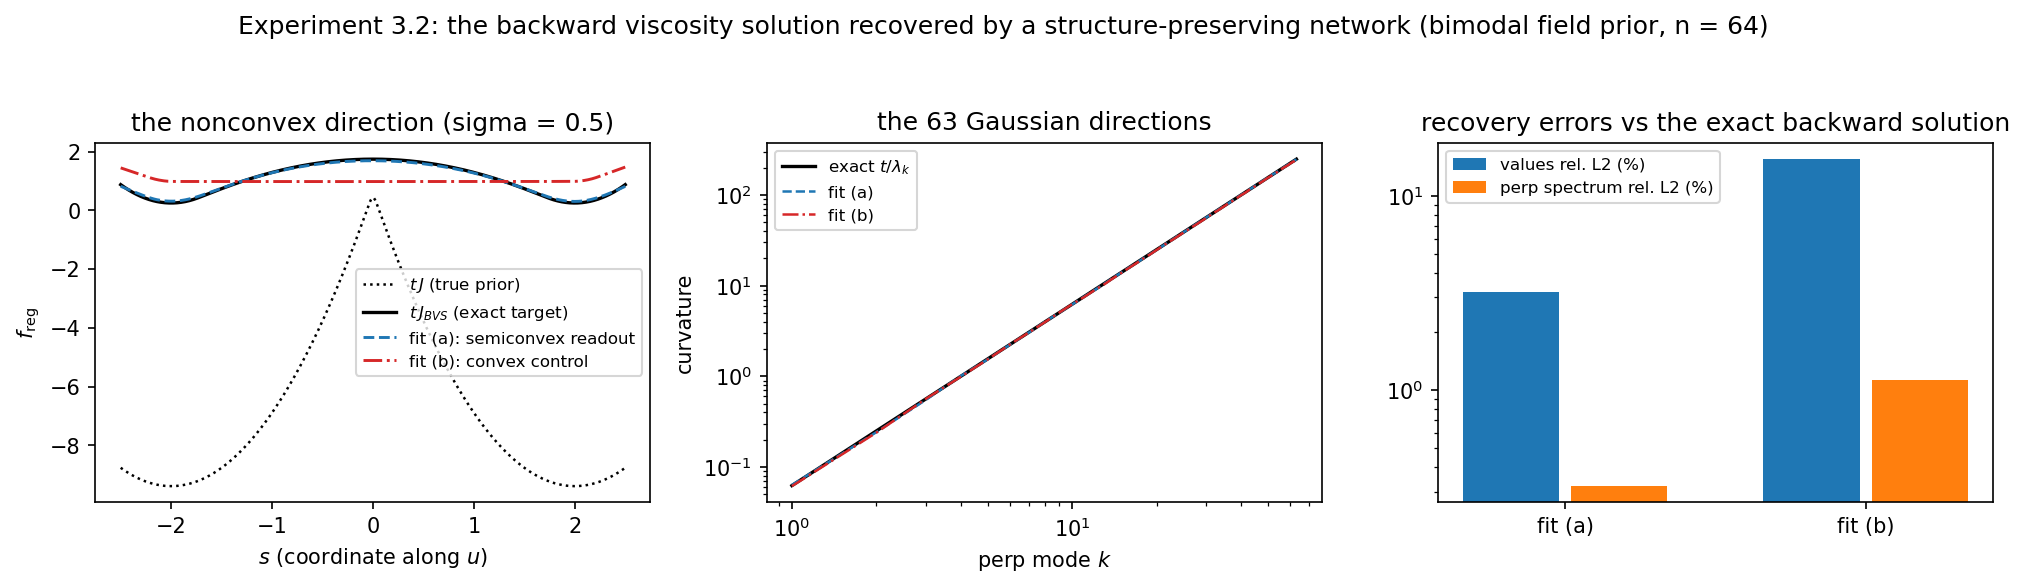

In [2]:
from IPython.display import Image, display
display(Image(filename=os.path.join(paths.FIGS, "experiment32_bimodal.png")))

## Reading

The semiconvex readout recovers the exact backward solution — value error 3.2%,
the nonconvex dip reproduced (min curvature −0.883 vs exact −0.911, floor −1),
spectrum 0.32% over four orders of magnitude (3.1% worst mode). The convex control fails exactly
along $u$ (min curvature 0.000: a convex function bridges the dip flat) while
matching the convex block — the class separation is categorical in curvature and
5× in value error, on identical data. On the convex block $J_{BVS} = J$ exactly,
and both fits agree below 1%: the no-information-loss identity, measured.
The spectrum is read by gradient-slice slopes anchored on the operating support; the failed instruments and their artifacts are in `DESIGN.md`, Experiment 3.2.